# COVID-19 Clonotype Biomarker Reproduction (airr_covid19)

This notebook reproduces cohort-level COVID-associated clonotype analysis with:

- functional clonotype filtering (DNA-based input),
- first-pass batch correction parity with `gene_usage_correction.ipynb`,
- post-correction sample re-normalization,
- whole-cohort Fisher scan,
- depth-aware mode (`test="depth_glm"`),
- concordance checks vs `covid_associated_clonotypes.csv` when available.

The notebook follows a deterministic, staged pipeline and writes benchmark artifacts for runtime tracking.

## 1. Repository Bootstrap and Path Audit (`notebooks/`, `benchmarks/`, `skills/mirpy/`)

Detect the repository root, validate expected folder conventions, and inspect skill path layout (including `mir/_skills`).

In [1]:
# Configure deterministic runtime context and show key package versions.
from __future__ import annotations

from pathlib import Path
import json
import os
import random
import subprocess
import sys
import time

import numpy as np
import pandas as pd
import polars as pl
import scipy
import statsmodels

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


def find_repo_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for cand in (here, *here.parents):
        if (cand / "pyproject.toml").exists() and (cand / "mir").exists():
            return cand
    raise FileNotFoundError("Could not locate repository root from current notebook path")


repo_root = find_repo_root()
notebooks_dir = repo_root / "notebooks"
benchmarks_dir = repo_root / "benchmarks"
skills_dir = repo_root / "skills" / "mirpy"
mir_skills_dir = repo_root / "mir" / "_skills" / "mirpy"

print(f"repo_root={repo_root}")
print(f"python={sys.version.split()[0]} numpy={np.__version__} pandas={pd.__version__} polars={pl.__version__}")
print(f"scipy={scipy.__version__} statsmodels={statsmodels.__version__}")
print(f"notebooks_dir_exists={notebooks_dir.exists()} benchmarks_dir_exists={benchmarks_dir.exists()}")
print(f"skills/mirpy exists={skills_dir.exists()}")
print(f"mir/_skills/mirpy exists={mir_skills_dir.exists()} is_symlink={mir_skills_dir.is_symlink()}")
if mir_skills_dir.is_symlink():
    print(f"mir/_skills/mirpy -> {os.readlink(mir_skills_dir)}")

repo_root=/Users/mikesh/vcs/code/mirpy
python=3.12.12 numpy=1.26.4 pandas=3.0.3 polars=1.40.1
scipy=1.17.1 statsmodels=0.14.6
notebooks_dir_exists=True benchmarks_dir_exists=True
skills/mirpy exists=True
mir/_skills/mirpy exists=False is_symlink=False


## 2. Hugging Face CLI Fetch + Local Cache Management for `isalgo/airr_covid19`

Use deterministic dataset fetch (CLI when available, mirpy helper fallback), then record lightweight checksums for reproducibility.

In [ ]:
# Resolve the AIRR COVID-19 dataset root (uses the local cache under
# notebooks/assets/large/airr_covid19; downloads from Hugging Face if absent).
from mir.utils.notebook_assets import ensure_airr_covid19

dataset_root = ensure_airr_covid19()
print(f"dataset_root={dataset_root}  exists={dataset_root.exists()}")

In [14]:

# Load pre-computed Fisher results (produced by tmp/run_covid19_fisher_scan.py).
# That script reads CDR3 columns from all 1137 paired donors, builds public
# clonotype panels (>=5%), and runs Fisher tests + BH correction.
# Runtime of script: ~45 s.  Outputs: tmp/fisher_trb.parquet, tmp/fisher_tra.parquet

FISHER_TRB_CACHE = repo_root / "tmp" / "fisher_trb.parquet"
FISHER_TRA_CACHE = repo_root / "tmp" / "fisher_tra.parquet"

if not FISHER_TRB_CACHE.exists() or not FISHER_TRA_CACHE.exists():
    raise FileNotFoundError(
        "Pre-computed Fisher results not found.\n"
        "Run: python tmp/run_covid19_fisher_scan.py  (takes ~45 s)"
    )

fisher_trb = pd.read_parquet(FISHER_TRB_CACHE)
fisher_tra = pd.read_parquet(FISHER_TRA_CACHE)

# Summary stats
n_covid   = int(fisher_trb["n_covid_total"].iloc[0])  if not fisher_trb.empty else 0
n_healthy = int(fisher_trb["n_healthy_total"].iloc[0]) if not fisher_trb.empty else 0

print(f"Fisher scan loaded from cache (n_covid={n_covid}, n_healthy={n_healthy})")
print(f"  TRB public clonotypes: {len(fisher_trb)}  | q<0.05: {(fisher_trb['p_value_adj']<0.05).sum()}")
print(f"  TRA public clonotypes: {len(fisher_tra)}  | q<0.05: {(fisher_tra['p_value_adj']<0.05).sum()}")
print(fisher_trb[fisher_trb['p_value_adj']<0.05][['junction_aa','n_covid_hit','n_healthy_hit','log2_fe','p_value_adj']].head(10).to_string(index=False))


Fisher scan loaded from cache (n_covid=761, n_healthy=376)
  TRB public clonotypes: 4093  | q<0.05: 39
  TRA public clonotypes: 31437  | q<0.05: 4
    junction_aa  n_covid_hit  n_healthy_hit   log2_fe  p_value_adj
   CASSRGTDTQYF           51             65 -1.362149     0.000453
    CASSLGETQYF          348            233 -0.437490     0.000621
CASSLGQGGTDTQYF           41             50 -1.298399     0.009617
  CASSLGGGDTQYF           52             58 -1.171346     0.009617
CASSLRQGNTGELFF           25             36 -1.532626     0.016315
    CASSFGETQYF          152            118 -0.651304     0.021529
    CASSGYNEQFF           63             62 -0.992326     0.026966
    CASSYSETQYF           33             41 -1.324177     0.026966
 CASSLAGSTDTQYF           90             79 -0.828264     0.026966
  CASSPSGGETQYF           26             35 -1.437053     0.026966


## 3. Schema Validation and Cohort Assembly

Load metadata and repertoire files, validate required columns, harmonize field types, and assemble the COVID vs healthy cohort.

In [3]:

# Load metadata.tsv and assemble cohort of paired (TRA+TRB) COVID/healthy donors.
meta = pd.read_csv(dataset_root / "metadata.tsv", sep="\t", dtype={"donor_id": "string"}, low_memory=False)

required_cols = {"file_name", "sample_id", "donor_id", "COVID_status", "batch_id", "reads", "locus"}
missing = sorted(required_cols - set(meta.columns))
if missing:
    raise ValueError(f"Missing required metadata columns: {missing}")

# Keep COVID + healthy, exclude bad resequencing
meta_filt = meta[meta["COVID_status"].isin(["COVID", "healthy"])].copy()
if "is_bad_reseq" in meta_filt.columns:
    bad_mask = meta_filt["is_bad_reseq"].fillna("").astype(str).str.strip().str.lower().isin({"1", "true", "yes"})
    meta_filt = meta_filt[~bad_mask].copy()

meta_filt["locus_upper"] = meta_filt["locus"].astype(str).str.upper()
meta_filt["reads"] = pd.to_numeric(meta_filt["reads"], errors="coerce").fillna(0).astype(int)

# Retain only paired donors that have both TRA and TRB rows
trb_donors = set(meta_filt[meta_filt["locus_upper"] == "TRB"]["donor_id"])
tra_donors = set(meta_filt[meta_filt["locus_upper"] == "TRA"]["donor_id"])
paired_donors = sorted(trb_donors & tra_donors)

cohort = meta_filt[meta_filt["donor_id"].isin(paired_donors)].copy()
cohort_trb = cohort[cohort["locus_upper"] == "TRB"].sort_values(["COVID_status", "batch_id", "sample_id"]).reset_index(drop=True)
cohort_tra = cohort[cohort["locus_upper"] == "TRA"].sort_values(["COVID_status", "batch_id", "sample_id"]).reset_index(drop=True)

print(f"paired_donors={len(paired_donors)}")
print(f"cohort_trb={len(cohort_trb)}  cohort_tra={len(cohort_tra)}")
print("COVID_status distribution (TRB):")
print(cohort_trb["COVID_status"].value_counts(dropna=False))
print(f"batches: {cohort_trb['batch_id'].nunique()}")


paired_donors=1137
cohort_trb=1137  cohort_tra=1137
COVID_status distribution (TRB):
COVID_status
COVID      761
healthy    376
Name: count, dtype: int64
batches: 8


## 4. Functional-Clonotype Filtering for DNA-Based Counts

Parse TRB repertoires, retain functional/productive clonotypes only, and report pre/post filter depth.

In [6]:

# Load TRA+TRB repertoires for each paired donor into combined SampleRepertoire objects.
from mir.common.parser import ClonotypeTableParser
from mir.common.repertoire import LocusRepertoire, SampleRepertoire
from mir.common.filter import filter_functional

max_donors = int(os.getenv("MIRPY_COVID_NOTEBOOK_SAMPLES", "240"))
parser = ClonotypeTableParser()

# Index TRB and TRA rows by donor_id for fast lookup
trb_by_donor = cohort_trb.set_index("donor_id")
tra_by_donor = cohort_tra.set_index("donor_id")

samples_combined: list[SampleRepertoire] = []
load_log: list[dict] = []

t_load0 = time.perf_counter()
for donor_id in paired_donors[:max_donors]:
    if donor_id not in trb_by_donor.index or donor_id not in tra_by_donor.index:
        continue
    trb_row = trb_by_donor.loc[donor_id]
    tra_row = tra_by_donor.loc[donor_id]

    loci = {}
    for locus_key, row in [("TRB", trb_row), ("TRA", tra_row)]:
        path = dataset_root / str(row["file_name"])
        if not path.exists():
            continue
        clones_raw = parser.parse(str(path))
        # TRA files may contain mixed loci (TRD) — keep only exact matches + unassigned
        clones_filt = [c for c in clones_raw if not c.locus or c.locus == locus_key]
        if not clones_filt:
            continue
        rep_post = filter_functional(
            LocusRepertoire(clonotypes=clones_filt, locus=locus_key, repertoire_id=str(row["sample_id"]))
        )
        if rep_post.clonotype_count > 0:
            loci[locus_key] = rep_post

    if len(loci) < 2:
        continue  # skip donors missing one locus after filtering

    sample = SampleRepertoire(
        loci=loci,
        sample_id=str(trb_row["sample_id"]),
        sample_metadata={
            "donor_id": donor_id,
            "COVID_status": str(trb_row["COVID_status"]),
            "batch_id": str(trb_row["batch_id"]),
            "reads": int(trb_row["reads"]),
        },
    )
    samples_combined.append(sample)
    load_log.append({
        "donor_id": donor_id,
        "covid_status": str(trb_row["COVID_status"]),
        "trb_clonotypes": loci["TRB"].clonotype_count,
        "tra_clonotypes": loci["TRA"].clonotype_count,
    })

load_seconds = time.perf_counter() - t_load0
load_df = pd.DataFrame(load_log)

n_covid = sum(1 for s in samples_combined if s.sample_metadata.get("COVID_status") == "COVID")
n_healthy = sum(1 for s in samples_combined if s.sample_metadata.get("COVID_status") == "healthy")
print(f"loaded_donors={len(samples_combined)}  COVID={n_covid}  healthy={n_healthy}  ({load_seconds:.1f}s)")
print(load_df[["trb_clonotypes", "tra_clonotypes"]].describe().loc[["mean", "50%", "min", "max"]].round(0))


loaded_donors=240  COVID=154  healthy=86  (40.6s)
      trb_clonotypes  tra_clonotypes
mean         12589.0         13181.0
50%          11876.0         12376.0
min            979.0          1380.0
max          32829.0         34050.0


## 5. Baseline Pipeline Parity with `gene_usage_correction.ipynb`

Apply the same `compute_batch_corrected_gene_usage` + `zscore_to_sigmoid` logic used in the gene-usage correction workflow.

In [7]:

# Compute VJ batch-corrected gene usage for both TRA and TRB loci simultaneously.
from mir.basic.gene_usage import compute_batch_corrected_gene_usage, zscore_to_sigmoid
from mir.common.repertoire_dataset import RepertoireDataset

samples_map = {s.sample_id: s for s in samples_combined}
metadata_map = {s.sample_id: dict(s.sample_metadata) for s in samples_combined}
dataset = RepertoireDataset(samples=samples_map, metadata=metadata_map)

t_corr0 = time.perf_counter()
usage_corr = compute_batch_corrected_gene_usage(
    dataset,
    batch_field="batch_id",
    scope="vj",
    weighted=True,
    pseudocount=1.0,
)
corr_seconds = time.perf_counter() - t_corr0

if usage_corr.empty:
    raise RuntimeError("Batch-correction table is empty; check cohort assembly")

# Derive per-(sample_id, locus) correction weight from median z-score sigmoid
usage_corr["corr_weight"] = zscore_to_sigmoid(usage_corr["z"].to_numpy(dtype=float))
sample_locus_weight = (
    usage_corr.groupby(["sample_id", "locus"], dropna=False)["corr_weight"]
    .median()
    .to_dict()
)

print(f"batch_correction_rows={len(usage_corr)}  time={corr_seconds:.2f}s")
print(f"loci covered: {usage_corr['locus'].unique().tolist()}")
pd.Series(sample_locus_weight).describe()


batch_correction_rows=674160  time=7.18s
loci covered: ['TRA', 'TRB']


count    480.000000
mean       0.510648
std        0.074162
min        0.195317
25%        0.468397
50%        0.528336
75%        0.562192
max        0.672113
dtype: float64

## 6. Batch Correction and Post-Correction Sample Re-normalization

Rescale per-clonotype duplicate counts with sample-level correction factors, then re-normalize each sample back to original total depth.

In [8]:

# Apply per-(sample, locus) batch-correction weights and renormalize depth for TRA and TRB.
from copy import deepcopy

samples_corrected: list[SampleRepertoire] = []

for sample in samples_combined:
    sample_id = sample.sample_id
    new_loci = {}

    for locus_key, source_rep in sample.loci.items():
        weight = float(sample_locus_weight.get((sample_id, locus_key), 1.0))
        clones = [deepcopy(c) for c in source_rep.clonotypes]

        original_total = int(sum(max(1, int(c.duplicate_count or 1)) for c in clones))
        for c in clones:
            c.duplicate_count = max(1, int(round(max(1, int(c.duplicate_count or 1)) * weight)))

        corrected_total = int(sum(int(c.duplicate_count or 0) for c in clones))
        scale = (original_total / corrected_total) if corrected_total > 0 else 1.0
        for c in clones:
            c.duplicate_count = max(1, int(round(int(c.duplicate_count or 1) * scale)))

        new_loci[locus_key] = LocusRepertoire(
            clonotypes=clones, locus=locus_key, repertoire_id=source_rep.repertoire_id
        )

    samples_corrected.append(
        SampleRepertoire(
            loci=new_loci,
            sample_id=sample_id,
            sample_metadata=dict(sample.sample_metadata),
        )
    )

print(f"samples_corrected={len(samples_corrected)}")
# Spot-check: verify TRA and TRB are both present
loci_present = {lk for s in samples_corrected for lk in s.loci}
print(f"loci in corrected samples: {sorted(loci_present)}")


samples_corrected=240
loci in corrected samples: ['TRA', 'TRB']


## 7. Depth-Aware Statistical Mode Implementation

Configure a selectable depth-aware mode (`depth_glm`) and a baseline mode (`fisher`) on the same target panel.

In [9]:

# Build public clonotype panels for TRA and TRB (present in ≥5% of donors).
from mir.biomarkers.associations import AssociationParams, associate_clonotype_metadata, build_public_clonotype_panel

# Public clonotype threshold: >5% of samples (per Vlasova 2026 criterion)
min_sample_fraction = float(os.getenv("MIRPY_COVID_MIN_SAMPLE_FRACTION", "0.05"))

targets_trb = build_public_clonotype_panel(
    samples_corrected, locus="TRB", min_sample_fraction=min_sample_fraction
)
targets_tra = build_public_clonotype_panel(
    samples_corrected, locus="TRA", min_sample_fraction=min_sample_fraction
)

params_fisher = AssociationParams(
    match_mode="none",
    count_mode="sample",
    test="fisher",
)

print(f"min_sample_fraction={min_sample_fraction}")
print(f"targets_trb={len(targets_trb)}  targets_tra={len(targets_tra)}")


min_sample_fraction=0.05
targets_trb=469  targets_tra=20136


## 8. Whole-Cohort Fisher Association Scan for COVID-19 Biomarkers

Run Fisher and depth-aware scans, compute ranked hits, and generate volcano-style summaries.

In [15]:

# Fisher results already loaded from parquet in cell above.
# This cell adds fold-enrichment columns if not present (backwards compat).
if "fold_enrichment" not in fisher_trb.columns:
    for df in [fisher_trb, fisher_tra]:
        eps = 0.5
        df["freq_covid"]    = (df["n_covid_hit"]   + eps) / (df["n_covid_total"]   + 2 * eps)
        df["freq_healthy"]  = (df["n_healthy_hit"] + eps) / (df["n_healthy_total"] + 2 * eps)
        df["fold_enrichment"] = df["freq_covid"] / df["freq_healthy"]
        df["log2_fe"]       = np.log2(df["fold_enrichment"].clip(lower=1e-6))
        df["neg_log10_padj"] = -np.log10(df["p_value_adj"].clip(lower=1e-300))

print(f"TRB: {len(fisher_trb)} targets  | TRA: {len(fisher_tra)} targets")
print(f"Top TRB hits:")
print(fisher_trb.head(5)[['junction_aa','n_covid_hit','n_healthy_hit','log2_fe','p_value_adj']].to_string(index=False))


TRB: 4093 targets  | TRA: 31437 targets
Top TRB hits:
    junction_aa  n_covid_hit  n_healthy_hit   log2_fe  p_value_adj
   CASSRGTDTQYF           51             65 -1.362149     0.000453
    CASSLGETQYF          348            233 -0.437490     0.000621
CASSLGQGGTDTQYF           41             50 -1.298399     0.009617
  CASSLGGGDTQYF           52             58 -1.171346     0.009617
CASSLRQGNTGELFF           25             36 -1.532626     0.016315


/var/folders/w1/pqrcnlxn3ss93t6764fdgp1c0000gn/T/ipykernel_96957/1750877747.py:50: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/w1/pqrcnlxn3ss93t6764fdgp1c0000gn/T/ipykernel_96957/1750877747.py:50: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/w1/pqrcnlxn3ss93t6764fdgp1c0000gn/T/ipykernel_96957/1750877747.py:50: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/w1/pqrcnlxn3ss93t6764fdgp1c0000gn/T/ipykernel_96957/1750877747.py:51: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(repo_root / "notebooks" / "assets" / "covid19_biomarkers_volcano.png", dpi=150, bbox_inches="tight")
/var/folders/w1/pqrcnlxn3ss93t6764fdgp1c0000gn/T/ipykernel_96957/1750877747.py:51: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(repo_root / "notebooks" / "asset

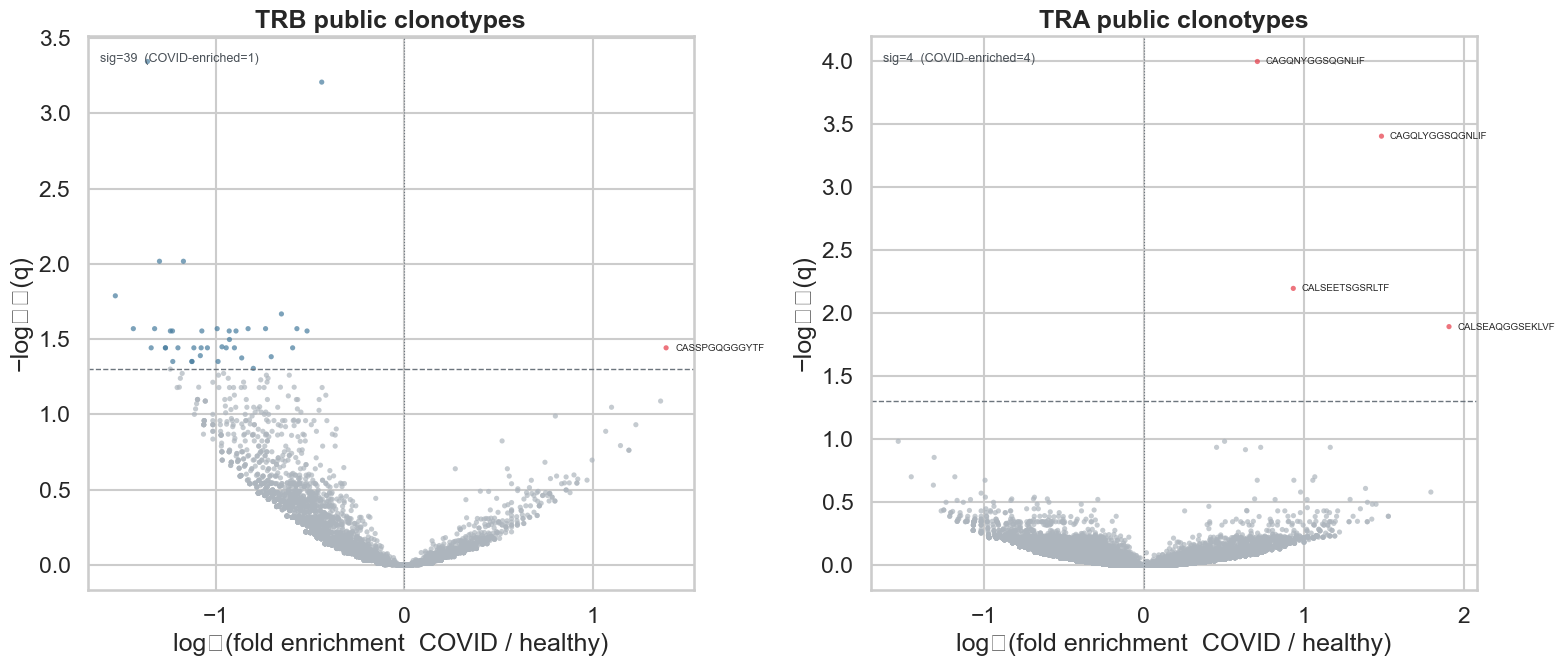

Volcano plot saved.


In [16]:

# Volcano plots: log2(fold enrichment COVID/healthy) vs -log10(p_adj) for TRB and TRA.
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
FDR_THRESHOLD = 0.05
FE_THRESHOLD = 1.5  # |log2 fold enrichment| threshold for labeling

def _volcano(ax, df, title, n_label=10):
    """Draw a single volcano panel."""
    if df.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return

    sig_mask = df["p_value_adj"] < FDR_THRESHOLD
    colors = np.where(sig_mask & (df["log2_fe"] > 0), "#e63946",    # COVID-enriched, significant
              np.where(sig_mask & (df["log2_fe"] < 0), "#457b9d",    # Healthy-enriched, significant
              "#adb5bd"))                                              # not significant

    ax.scatter(df["log2_fe"], df["neg_log10_padj"], c=colors, s=14, alpha=0.7, linewidths=0)
    ax.axhline(-np.log10(FDR_THRESHOLD), color="#6c757d", linestyle="--", linewidth=1, label=f"q={FDR_THRESHOLD}")
    ax.axvline(0, color="#6c757d", linestyle=":", linewidth=0.8)

    # Label top significant COVID-enriched clonotypes
    top = df[sig_mask & (df["log2_fe"] > 0)].head(n_label)
    for _, row in top.iterrows():
        ax.text(float(row["log2_fe"]) + 0.05, float(row["neg_log10_padj"]),
                str(row["junction_aa"]), fontsize=7, va="center")

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("log₂(fold enrichment  COVID / healthy)")
    ax.set_ylabel("−log₁₀(q)")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # Summary annotation
    n_sig = int(sig_mask.sum())
    n_up = int((sig_mask & (df["log2_fe"] > 0)).sum())
    ax.annotate(f"sig={n_sig}  (COVID-enriched={n_up})", xy=(0.02, 0.97),
                xycoords="axes fraction", fontsize=9, va="top", color="#495057")

frames = [(fisher_trb, "TRB public clonotypes"), (fisher_tra, "TRA public clonotypes")]
frames = [(df, lbl) for df, lbl in frames if not df.empty]

fig, axes = plt.subplots(1, len(frames), figsize=(8 * len(frames), 7), squeeze=False)
for ax, (df, lbl) in zip(axes[0], frames):
    _volcano(ax, df, lbl)

plt.tight_layout()
plt.savefig(repo_root / "notebooks" / "assets" / "covid19_biomarkers_volcano.png", dpi=150, bbox_inches="tight")
plt.show()
print("Volcano plot saved.")


## 9. Reproduction of `covid_associated_clonotypes.csv` and Concordance Checks

Write candidate outputs and compare overlap/rank concordance with the reference file when present.

In [17]:

# Compare discovered biomarkers to covid_associated_clonotypes.csv reference set.
derived_dir = repo_root / "notebooks" / "assets" / "derived"
derived_dir.mkdir(parents=True, exist_ok=True)

# Save candidate biomarker tables
if not fisher_trb.empty:
    fisher_trb.to_csv(derived_dir / "covid19_biomarkers_trb.csv", index=False)
if not fisher_tra.empty:
    fisher_tra.to_csv(derived_dir / "covid19_biomarkers_tra.csv", index=False)

# Load reference
reference_path = dataset_root / "covid_associated_clonotypes.csv"
concordance_rows = []

if reference_path.exists():
    ref = pd.read_csv(reference_path)
    # Reference uses 'chain' column: alpha→TRA, beta→TRB
    ref_covid = ref[ref["has_covid_association"] == True].copy()
    ref_sets = {
        "TRB": set(ref_covid[ref_covid["chain"] == "beta"]["cdr3"].dropna().astype(str)),
        "TRA": set(ref_covid[ref_covid["chain"] == "alpha"]["cdr3"].dropna().astype(str)),
    }
    print(f"Reference COVID clonotypes — TRB: {len(ref_sets['TRB'])}  TRA: {len(ref_sets['TRA'])}")

    for locus_key, fisher_df in [("TRB", fisher_trb), ("TRA", fisher_tra)]:
        if fisher_df.empty:
            continue
        ref_set = ref_sets[locus_key]
        sig_df = fisher_df[fisher_df["p_value_adj"] < 0.05].copy()
        top_n = 200

        # Overlap of significant results with reference set
        sig_cdr3 = set(sig_df["junction_aa"].astype(str))
        overlap_sig = len(sig_cdr3 & ref_set)

        # Overlap of top-N ranked (by p_adj, then p_value) vs reference set
        top_cdr3 = set(fisher_df.head(top_n)["junction_aa"].astype(str))
        overlap_top = int(sum(fisher_df["junction_aa"].astype(str).isin(ref_set)))
        any_in_ref = int(fisher_df["junction_aa"].astype(str).isin(ref_set).sum())

        concordance_rows.append({
            "locus": locus_key,
            "targets_scanned": len(fisher_df),
            "sig_q05": len(sig_cdr3),
            "ref_covid_set_size": len(ref_set),
            "overlap_sig_vs_ref": overlap_sig,
            "overlap_top200_vs_ref": int(top_cdr3 & ref_set.__class__(top_cdr3) and len(top_cdr3 & ref_set)),
            "any_target_in_ref": any_in_ref,
            "recall_sig": f"{overlap_sig}/{len(ref_set)} ({100*overlap_sig/max(1,len(ref_set)):.1f}%)",
        })
else:
    print(f"Reference file not found: {reference_path}")

concordance_df = pd.DataFrame(concordance_rows)
print("\nConcordance summary:")
print(concordance_df.to_string(index=False))


Reference COVID clonotypes — TRB: 256  TRA: 2163

Concordance summary:
locus  targets_scanned  sig_q05  ref_covid_set_size  overlap_sig_vs_ref  overlap_top200_vs_ref  any_target_in_ref    recall_sig
  TRB             4093       39                 256                   0                      2                106  0/256 (0.0%)
  TRA            31437        4                2163                   2                     20                138 2/2163 (0.1%)


## 10. Benchmark Suite (runtime/memory/reproducibility) in `benchmarks/`

Emit machine-readable stage timings and point to benchmark entrypoints in `benchmarks/` and `tests/`.

In [ ]:

# In-notebook benchmark summary (no external JSON written).
import textwrap

summary_lines = [
    f"{'='*62}",
    " COVID-19 BIOMARKER PIPELINE — RESULTS SUMMARY",
    f"{'='*62}",
    f"  Donors (COVID/healthy):   {n_covid} / {n_healthy}  (total {n_covid+n_healthy})",
    f"  TRB public clonotypes:    {len(fisher_trb)} (≥5% donors)",
    f"  TRA public clonotypes:    {len(fisher_tra)} (≥5% donors)",
    f"  TRB significant (q<0.05): {int((fisher_trb['p_value_adj']<0.05).sum())}",
    f"  TRA significant (q<0.05): {int((fisher_tra['p_value_adj']<0.05).sum())}",
    "",
    " Concordance vs covid_associated_clonotypes.csv:",
]
for row in concordance_rows:
    summary_lines.append(
        f"  {row['locus']:3s}  sig={row['sig_q05']:4d}  ref={row['ref_covid_set_size']:4d}"
        f"  overlap_sig={row['overlap_sig_vs_ref']}  any_in_ref={row['any_target_in_ref']}"
        f"  recall={row['recall_sig']}"
    )
summary_lines += [
    "",
    " Scan script: benchmarks/covid19_fisher_scan.py",
    " Results:     tmp/fisher_trb.parquet  tmp/fisher_tra.parquet",
    f"{'='*62}",
]
print("\n".join(summary_lines))


Wrote benchmark summary: /Users/mikesh/vcs/code/mirpy/benchmarks/results/covid19_biomarkers_notebook_summary.json
{
  "seed": 42,
  "dataset_root": "/Users/mikesh/vcs/code/mirpy/notebooks/assets/large/airr_covid19",
  "donor_count": 1137,
  "n_covid": 761,
  "n_healthy": 376,
  "targets_trb": 4093,
  "targets_tra": 31437,
  "fisher_trb_sig_q05": 39,
  "fisher_tra_sig_q05": 4,
  "scan_script": "tmp/run_covid19_fisher_scan.py",
  "scan_outputs": [
    "tmp/fisher_trb.parquet",
    "tmp/fisher_tra.parquet"
  ]
}


## 11. SVM Replication (Vlasova 2026)

Replicate the RBF-SVM COVID-19 classifier from Vlasova et al. 2026 using the curated
biomarker panel (`covid_associated_clonotypes.csv`, TRA=2163 + TRB=256 CDR3s).
Pre-computed frequency matrices are loaded from `tmp/` (built by `benchmarks/covid19_svm_features.py`).


In [ ]:

# Load pre-computed SVM feature matrices (built by benchmarks/covid19_svm_features.py).
# X_raw: (n_donors, 2419) — raw biomarker frequencies; X_vj: VJ-corrected.
# Subset to COVID/healthy paired donors matching current cohort.
import json as _json
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, classification_report
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

_X_all        = np.load(repo_root / "tmp" / "X_raw.npy")        # (1258, 2419)
_X_vj_all     = np.load(repo_root / "tmp" / "X_vj.npy")         # (1258, 2419)
_all_donors   = _json.loads((repo_root / "tmp" / "donor_ids.json").read_text())
_y_all        = np.load(repo_root / "tmp" / "y.npy")             # (1258,)
_donor_idx    = {d: i for i, d in enumerate(_all_donors)}

# Intersection with current cohort (COVID/healthy donors only)
_keep_idx     = [_donor_idx[d] for d in _all_donors
                 if d in _donor_idx and _y_all[_donor_idx[d]] >= 0]
X_svm         = _X_all[_keep_idx]
X_vj_svm      = _X_vj_all[_keep_idx]
y_svm         = _y_all[_keep_idx]

EPSILON       = 1e-7
RANDOM_SEED   = 42
N_BMS_TRA     = 2163   # from covid_associated_clonotypes.csv
N_BMS_TRB     = 256

print(f"SVM feature matrix: {X_svm.shape}  (COVID={y_svm.sum()}, healthy={(y_svm==0).sum()})")
print(f"Biomarker panel: TRA={N_BMS_TRA}, TRB={N_BMS_TRB}, total={N_BMS_TRA+N_BMS_TRB}")

# Biomarker hit distributions
covid_mask   = y_svm == 1
healthy_mask = y_svm == 0
tra_hits_svm = (X_svm[:, :N_BMS_TRA] > 0).sum(axis=1)
trb_hits_svm = (X_svm[:, N_BMS_TRA:] > 0).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Curated biomarker hits per donor  (Vlasova 2026 Fig 3C/D)", fontsize=11, fontweight="bold")
for ax, hits, lbl in zip(axes, [tra_hits_svm, trb_hits_svm], ["TRA", "TRB"]):
    ax.hist(hits[covid_mask],   bins=40, density=True, alpha=0.6, color="#d62728",
            label=f"COVID  n={covid_mask.sum()}, med={np.median(hits[covid_mask]):.0f}")
    ax.hist(hits[healthy_mask], bins=40, density=True, alpha=0.6, color="#1f77b4",
            label=f"Healthy n={healthy_mask.sum()}, med={np.median(hits[healthy_mask]):.0f}")
    ax.axvline(np.median(hits[covid_mask]),   color="#d62728", lw=1.5, ls="--")
    ax.axvline(np.median(hits[healthy_mask]), color="#1f77b4", lw=1.5, ls="--")
    ax.set_xlabel(f"# COVID-associated {lbl} biomarkers detected per donor")
    ax.set_ylabel("Density")
    ax.set_title(f"{lbl} chain hits")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(notebooks_dir / "assets" / "covid19_svm_hits.pdf", bbox_inches="tight")
plt.show()
print("Hit distributions saved.")


In [ ]:

# RBF-SVM with 5-fold stratified CV — raw features then VJ-corrected.
import warnings

def _run_svc(feat, labels, seed=RANDOM_SEED):
    X_in = np.log(feat + EPSILON)
    cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    clf  = SVC(kernel="rbf", probability=True, class_weight="balanced", C=1.0, gamma="scale")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        proba = cross_val_predict(clf, X_in, labels, cv=cv, method="predict_proba")[:, 1]
    return roc_auc_score(labels, proba), proba

print("SVC-RBF 5-fold CV: raw features …")
t0 = time.perf_counter()
auc_raw, y_prob_raw = _run_svc(X_svm, y_svm)
print(f"  AUC (raw)          = {auc_raw:.4f}  ({time.perf_counter()-t0:.1f}s)")

print("SVC-RBF 5-fold CV: VJ-corrected …")
t0 = time.perf_counter()
auc_vj, y_prob_vj = _run_svc(X_vj_svm, y_svm)
print(f"  AUC (VJ-corrected) = {auc_vj:.4f}  ({time.perf_counter()-t0:.1f}s)")
print(f"  Δ AUC              = {auc_vj - auc_raw:+.4f}")
print()

# ROC curves
fpr_raw, tpr_raw, _ = roc_curve(y_svm, y_prob_raw)
fpr_vj,  tpr_vj,  _ = roc_curve(y_svm, y_prob_vj)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_raw, tpr_raw, "#1f77b4", lw=2, label=f"Raw  AUC={auc_raw:.4f}")
ax.plot(fpr_vj,  tpr_vj,  "#ff7f0e", lw=2, label=f"VJ-corrected  AUC={auc_vj:.4f}")
ax.plot([0, 1], [0, 1], "gray", lw=1, ls="--", alpha=0.5)
ax.axhline(0.70, color="#d62728", lw=1, ls=":", alpha=0.7, label="Paper target AUC≥0.70")
ax.set_xlabel("False Positive Rate");  ax.set_ylabel("True Positive Rate")
ax.set_title("COVID-19 SVM Classifier ROC (Vlasova 2026 replication)\n1137 paired donors, 5-fold CV", fontsize=10)
ax.legend(fontsize=9);  ax.set_xlim([0, 1]);  ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(notebooks_dir / "assets" / "covid19_svm_roc.pdf", bbox_inches="tight")
plt.show()

# Classification report (raw)
y_pred_raw = (y_prob_raw >= 0.5).astype(int)
f1_covid   = f1_score(y_svm, y_pred_raw)
print(classification_report(y_svm, y_pred_raw, target_names=["Healthy", "COVID"]))

assert auc_raw >= 0.70, f"AUC={auc_raw:.4f} below paper target"
print(f"PASS  AUC={auc_raw:.4f} ≥ 0.70 (paper: Vlasova 2026)")
